# Lung Dataset Analysis

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from openpyxl import load_workbook
import os

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier  # or any classifier of your choice
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
import shap


/home2/poorvi.c/miniconda3/envs/research/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home2/poorvi.c/miniconda3/envs/research/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def read_file(file, index=False):
    file_ext = os.path.splitext(file)[1].lower()
    
    if file_ext == '.xlsx':
        if index:
            data = pd.read_excel(file, index_col=0)
        else:
            data = pd.read_excel(file)
    
    elif file_ext == '.csv':
        if index:
            data = pd.read_csv(file, index_col=0)
        else:
            data = pd.read_csv(file)
    
    elif file_ext == '.txt':
        data = pd.read_csv(file, header=None, names=['Gene'])
        data['Gene'] = data['Gene'].str.strip()
    
    else:
        raise ValueError(f"Unsupported file format: {file_ext}. Supported formats are: .xlsx, .csv, .txt")
    
    return data


In [3]:
# derive the combined_gene_list (combination of all the three way conserved gene lists)
file = "../../results/module_comparison/three_way_module_associations_significant.csv"
associations = read_file(file)
def parse_gene_list(list_string):
    cleaned = list_string.strip('[]').split(', ')
    return [gene.strip().strip("'\"") for gene in cleaned]

associations["genes"] = associations["genes"].apply(parse_gene_list)

combined_gene_list = [gene for gene_list in associations["genes"] for gene in gene_list]
len(combined_gene_list)

172

In [4]:
# process RATs list of genes
rats = pd.read_excel('../../data/rats.xlsx', header=None)
rats.columns = ['gene']
rats = rats['gene'].tolist()
print(len(rats))

def process_rats(rats):
    processed_rats = []
    for gene in rats:
        if gene != '':
            if "///" in str(gene):
                genes = gene.split("///")
                for i in genes:
                    processed_rats.append(i.replace('/', '').replace(' ', ''))
            else:
                processed_rats.append(str(gene).replace('/', '').replace(' ', ''))
    return processed_rats

processed_rats = process_rats(rats)
rats = list(np.unique(processed_rats))
print(len(rats))

454
350


### ML utility functions

In [9]:
# function to produce a subset of the expression matrix given a list of genes
def filter_genes(data, genes):
    genes = [gene for gene in genes if gene in data.columns]
    data = data[genes]
    return data

In [10]:
num_folds = 10
skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

In [11]:
def mean_ci(values, confidence=0.95):
    values = np.array(values)
    mean = np.mean(values)
    se = np.std(values, ddof=1) / np.sqrt(len(values))
    z = 1.96  # 95% CI
    lower = mean - z * se
    upper = mean + z * se
    return mean, lower, upper

In [12]:
def avg_acc_auc(X, y, model_type="rndm"):
    accuracies = []
    aucs = []
    best_auc = 0
    best_model = None

    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        if model_type == "rndm":
            clf = RandomForestClassifier(n_estimators=100, random_state=42)
            clf.fit(X_train, y_train)
            
        elif model_type == "svm":
            clf = Pipeline([
                ('scaler', StandardScaler()),
                ('svm', SVC(kernel='linear', C=1.0, probability=True, random_state=42))
            ])
            clf.fit(X_train, y_train)
            
        elif model_type == "lasso":
            clf = Pipeline([
                ('scaler', StandardScaler()),
                ('lasso', LogisticRegression(penalty='l1', C=0.1, solver='liblinear', random_state=42))
            ])
            clf.fit(X_train, y_train)

        if model_type == "rndm":
            y_pred = clf.predict(X_test)
            y_pred_proba = clf.predict_proba(X_test)[:, 1]
        else:
            y_pred = clf.predict(X_test)
            y_pred_proba = clf.predict_proba(X_test)[:, 1]
            
        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)
        
        accuracies.append(accuracy)
        aucs.append(auc)

        if auc > best_auc:
            best_auc = auc
            best_model = clf
    
    if model_type == "rndm":
        feature_importance = best_model.feature_importances_
    elif model_type == "svm":
        feature_importance = np.abs(best_model.named_steps['svm'].coef_[0])
    elif model_type == "lasso":
        feature_importance = np.abs(best_model.named_steps['lasso'].coef_[0])

            
    return accuracies, aucs, best_model, feature_importance if best_model is not None else None

def get_train_test_gap(model, X, y):
    train_scores = []
    test_scores = []
    
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        if hasattr(model, 'fit'):
            model.fit(X_train, y_train)
            train_score = model.score(X_train, y_train)
            test_score = model.score(X_test, y_test)
        else:  
            model.fit(X_train, y_train)
            train_score = model.score(X_train, y_train)
            test_score = model.score(X_test, y_test)
            
        train_scores.append(train_score)
        test_scores.append(test_score)
    
    return np.mean(train_scores) - np.mean(test_scores)


def compare_models(data, meta, category, genes_list, models=["rndm", "svm", "lasso"]):
    results = []
    
    for model_type in models:
        X = filter_genes(data, genes_list)
        y = meta[category]
        
        accuracies, aucs, best_model, _ = avg_acc_auc(X, y, model_type)
        
        mean_auc, lower_auc, upper_auc = mean_ci(aucs)
        mean_acc, lower_acc, upper_acc = mean_ci(accuracies)

        results.append({
            'model': model_type,
            'accuracy_mean': mean_acc,
            'accuracy_ci_lower': lower_acc,
            'accuracy_ci_upper': upper_acc,
            'std_acc': np.std(accuracies),
            'std_auc': np.std(aucs),
            'auc_mean': mean_auc,
            'auc_ci_lower': lower_auc,
            'auc_ci_upper': upper_auc,
            'train_test_gap': get_train_test_gap(best_model, X, y) if best_model is not None else None
        })

    return pd.DataFrame(results)

In [13]:
def get_feature_importances(data, meta, category, genes, model_type="lasso"):
    overlap = [gene for gene in genes if gene in data.columns]
    X = filter_genes(data, overlap)
    y = meta[category]
    accuracies, aucs, best_model, feature_importance = avg_acc_auc(X, y, model_type)
    print(np.mean(accuracies), np.mean(aucs))

    builtin_importance = pd.Series(feature_importance, index=X.columns).sort_values(ascending=False)

    perm_imp = permutation_importance(best_model, X, y, n_repeats=10, random_state=42, scoring='roc_auc')
    permutation_importance_scores = pd.Series(perm_imp.importances_mean, index=X.columns).sort_values(ascending=False)

    try:
        if hasattr(best_model, 'named_steps'):
            if 'lasso' in best_model.named_steps:
                model_for_shap = best_model.named_steps['lasso']
                X_scaled = best_model.named_steps['scaler'].transform(X)
                explainer = shap.LinearExplainer(model_for_shap, X_scaled)
                shap_values = explainer.shap_values(X_scaled)
            elif 'svm' in best_model.named_steps:
                model_for_shap = best_model.named_steps['svm']
                X_scaled = best_model.named_steps['scaler'].transform(X)
                explainer = shap.LinearExplainer(model_for_shap, X_scaled)
                shap_values = explainer.shap_values(X_scaled)
        else:
            explainer = shap.TreeExplainer(best_model)
            shap_values = explainer.shap_values(X)
            
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
            elif len(shap_values.shape) == 3:
                shap_values = shap_values[:, :, 1]
                
    except Exception as e:
        print(f"TreeExplainer failed with error: {e}")
        print("Falling back to general Explainer...")
        
        explainer = shap.Explainer(best_model, X)
        shap_values = explainer(X).values
        
        if len(shap_values.shape) == 3:
            shap_values = shap_values[:, :, 1]
        elif len(shap_values.shape) == 2 and shap_values.shape[1] != X.shape[1]:
            if shap_values.shape[1] == 2:
                print(f"Warning: Unexpected SHAP output shape {shap_values.shape}")
                print("SHAP values should have shape (n_samples, n_features)")
                print("Check your model and data setup")
                return None

    if len(shap_values.shape) != 2 or shap_values.shape[1] != X.shape[1]:
        print(f"Error: SHAP values have shape {shap_values.shape}, expected ({X.shape[0]}, {X.shape[1]})")
        return None

    shap_importance_scores = pd.Series(
        np.abs(shap_values).mean(axis=0), 
        index=X.columns
    ).sort_values(ascending=False)
    
    importance_df = pd.DataFrame({
        'builtin': builtin_importance,
        'permutation': permutation_importance_scores,
        'shap': shap_importance_scores
    })

    for col in importance_df.columns:
        importance_df[col] = (importance_df[col] - importance_df[col].min()) / (importance_df[col].max() - importance_df[col].min())

    importance_df['consensus'] = importance_df.mean(axis=1)
    consensus_ranking = importance_df.sort_values('consensus', ascending=False)
    print("Top 10 features by consensus:")
    print(consensus_ranking.head(10))

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    builtin_importance.head(10).plot(kind='barh', ax=axes[0,0], title='Built-in Importance')
    permutation_importance_scores.head(10).plot(kind='barh', ax=axes[0,1], title='Permutation Importance')
    shap_importance_scores.head(10).plot(kind='barh', ax=axes[1,0], title='SHAP Importance')
    consensus_ranking['consensus'].head(10).plot(kind='barh', ax=axes[1,1], title='Consensus Ranking')
    plt.tight_layout()
    plt.show()

    shap.summary_plot(shap_values, X, plot_type="bar", max_display=15)
    shap.summary_plot(shap_values, X, max_display=15)
    return consensus_ranking['consensus']

### Biomarker Validation

In [14]:
data_liver = read_file('../../data/GSE145780_liver.csv', index=True)
meta_liver = read_file('../../data/liver_meta.xlsx', index=True)
data_kidney = read_file("../../data/GSE192444_kidney.csv", index=True)
meta_kidney = read_file('../../data/kidney_meta.xlsx', index=True)
data_heart = read_file("../../data/GSE272655_heart.csv", index=True)
meta_heart = read_file('../../data/heart_meta.xlsx', index=True)

In [24]:
twenty_gene_biomarker = ['KLRD1','FCGR1A','NKG7','CXCL11','CXCL9','PRF1','MSR1',
'EOMES','APOL3','SAMD3','IRF8','GBP1','HLA-F','RUNX3','STAT1','TRAF5','CSF2RA',
'CCL5','HCP5','ENTPD1']

six_gene_biomarker = ['KLRD1','FCGR1A','NKG7','CXCL11','CXCL9','PRF1']

cell_cycle_genes = ['ANLN','ASPM','BUB1','BUB1B','CCNA2','CCNB1','CDKN3','CENPA','CENPF','CEP55','DLGAP5','DTL','EZH2','KIAA0101','KIF11','KIF20A','MKI67','NUSAP1','RRM2','TOP2A','TPX2','TTK','TYMS','UBE2C']

#### 20 gene biomarker performance on organs (liver, kidney, heart)

In [18]:
compare_models(data_liver, meta_liver, "classes", twenty_gene_biomarker)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.932428,0.897273,0.967582,0.053808,0.015674,0.989371,0.979130,0.999611,0.067572
1,svm,0.885145,0.845850,0.924440,0.060145,0.032946,0.962331,0.940807,0.983855,0.049128
2,lasso,0.863587,0.817273,0.909901,0.070889,0.036355,0.944744,0.920992,0.968495,0.021515


In [19]:
compare_models(data_kidney, meta_kidney, "group", twenty_gene_biomarker)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.910000,0.886044,0.933956,0.036667,0.043708,0.955216,0.926660,0.983772,0.090000
1,svm,0.946667,0.922416,0.970917,0.037118,0.038431,0.971652,0.946544,0.996761,0.020370
2,lasso,0.920000,0.884615,0.955385,0.054160,0.036896,0.959825,0.935719,0.983930,0.000741


In [20]:
compare_models(data_heart, meta_heart, "group", twenty_gene_biomarker)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.956593,0.925404,0.987783,0.047739,0.046069,0.965972,0.935874,0.996071,0.043407
1,svm,0.890659,0.859264,0.922055,0.048054,0.049749,0.955000,0.922497,0.987503,0.068789
2,lasso,0.920330,0.876357,0.964302,0.067305,0.040346,0.967222,0.940863,0.993581,0.013174


#### 6 gene biomarker performance on organs (liver, kidney, heart)

In [21]:
compare_models(data_liver, meta_liver, "classes", six_gene_biomarker)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.923188,0.898885,0.947492,0.037199,0.033885,0.954202,0.932063,0.976340,0.076812
1,svm,0.884420,0.837265,0.931576,0.072177,0.055049,0.937622,0.901657,0.973588,0.009179
2,lasso,0.841486,0.780293,0.902678,0.093662,0.049328,0.938380,0.906153,0.970607,0.013345


In [22]:
compare_models(data_kidney, meta_kidney, "group", six_gene_biomarker)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.900000,0.866262,0.933738,0.051640,0.046523,0.958357,0.927962,0.988753,0.100000
1,svm,0.910000,0.877625,0.942375,0.049554,0.031160,0.964813,0.944455,0.985170,0.015556
2,lasso,0.906667,0.865576,0.947757,0.062893,0.037127,0.960751,0.936494,0.985007,0.008148


In [23]:
compare_models(data_heart, meta_heart, "group", six_gene_biomarker)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.913187,0.872643,0.953730,0.062056,0.050389,0.968750,0.935829,1.001671,0.086813
1,svm,0.920330,0.881625,0.959034,0.059241,0.042040,0.959722,0.932256,0.987188,0.004244
2,lasso,0.920330,0.876357,0.964302,0.067305,0.040620,0.962222,0.935684,0.988761,0.005057


## External Validation on the Lung Dataset

In [41]:
data_lung = read_file("../../data/GSE125004_lung.csv", index=True)
meta_lung = read_file("../../data/GSE125004_sample_info.csv", index=True)

In [42]:
data_lung.index = meta_lung.index
data_lung

,HIST1H3G,TNFAIP8L1,OTOP2,C17orf78,LOC285501,SAMD7,ARRDC5,C1orf173,FAM86C,HIST1H2BI,...,Empty_114,Empty_115,Empty_116,Empty_117,Empty_118,Empty_119,Empty_120,Empty_121,Empty_122,Empty_123
GSM4046057,4.67325,9.1495,5.8190,3.470,3.1820,3.470,5.699,11.150,7.853000,3.128333,...,2.841,3.138,3.144,3.105,3.541,3.321,2.719,3.142,2.933,3.555
GSM4046058,4.75125,8.9950,5.7275,3.403,3.5375,3.662,5.809,11.008,8.209667,3.413333,...,2.807,3.273,3.320,3.283,3.506,3.434,2.898,3.086,2.983,3.454
GSM4046059,4.64775,8.3780,6.0645,3.546,3.4965,3.814,5.823,10.206,7.864667,3.159000,...,3.017,3.233,3.189,3.226,3.480,3.376,2.820,3.175,3.036,3.550
GSM4046060,4.74650,8.0035,6.0695,3.414,3.3935,3.694,5.728,9.362,7.764000,3.174000,...,2.896,3.125,3.153,3.203,3.533,3.328,2.712,3.372,3.064,3.573
GSM4046061,5.06200,8.6635,6.2345,3.580,3.7535,3.626,6.167,9.882,8.103333,3.248000,...,2.937,3.323,3.447,3.148,3.718,3.503,2.790,3.323,3.026,3.948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM4046295,4.70850,7.4345,5.8720,3.590,3.4960,3.503,5.857,8.616,7.762000,3.143667,...,2.877,3.362,3.280,3.111,3.557,3.592,2.821,3.091,3.021,3.646
GSM4046296,4.92000,8.9680,6.1975,3.535,3.5075,3.595,6.028,10.813,8.374333,3.214333,...,2.948,3.228,3.289,3.262,3.642,3.661,2.820,3.250,3.094,3.887
GSM4046297,4.95125,8.5735,6.1200,3.636,3.6525,3.744,6.138,10.228,8.188667,3.327333,...,2.898,3.376,3.560,3.276,3.590,3.602,2.842,3.154,3.107,3.841
GSM4046298,4.87325,7.7670,5.8900,3.410,3.4890,3.425,6.148,8.896,7.950667,2.976333,...,2.941,3.303,3.320,3.083,3.643,3.549,2.797,3.131,3.042,3.838


In [43]:
meta_lung['group'] = np.where(meta_lung['cluster (1, 2, 3, 4):ch1'] != '1', 'treatment', 'control')

In [44]:
overlap = [gene for gene in rats if gene in data_lung.columns]
print(len(overlap))

304


In [45]:
# rats performance
compare_models(data_lung, meta_lung, "group", overlap)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.934000,0.903639,0.964361,0.046471,0.017615,0.989072,0.977564,1.000581,0.066000
1,svm,0.930333,0.896554,0.964113,0.051703,0.021090,0.976766,0.962987,0.990545,0.069667
2,lasso,0.954833,0.926571,0.983096,0.043259,0.024166,0.985970,0.970182,1.001759,0.017734


In [46]:
# individual 3 way module performance
for i in range(1,7):
    file = f"../../results/module_comparison/three_way_conserved_genes_{i}.txt"
    gene_list = list(read_file(file)['Gene'])
    print(f"3 way combination {i}")
    three_way_performance = compare_models(data_lung, meta_lung, "group", gene_list)
    print(three_way_performance)
    print("\n")

3 way combination 1
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.946333           0.921720           0.970947  0.037674   
1    svm       0.934667           0.893468           0.975866  0.063060   
2  lasso       0.946167           0.916160           0.976174  0.045929   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.044658  0.977731      0.948554      1.006908        0.053667  
1  0.022939  0.983272      0.968285      0.998259        0.049787  
2  0.024133  0.984185      0.968418      0.999951        0.006278  


3 way combination 2
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.925667           0.893800           0.957533  0.048775   
1    svm       0.926167           0.900408           0.951926  0.039427   
2  lasso       0.934333           0.907023           0.961643  0.041801   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.038962  0.9

In [47]:
for i in range(1,4):
    file = f"../../results/module_comparison/conserved_group_{i}_genes.txt"
    gene_list = list(read_file(file)['Gene'])
    print(f"combination network {i}")
    two_way_performance = compare_models(data_lung, meta_lung, "group", gene_list)
    print(two_way_performance)
    print("\n")

combination network 1
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.925833           0.896501           0.955166  0.044896   
1    svm       0.946500           0.929191           0.963809  0.026494   
2  lasso       0.958833           0.934720           0.982947  0.036909   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.018491  0.989440      0.977359      1.001521        0.074167  
1  0.011458  0.986889      0.979403      0.994375        0.053500  
2  0.025385  0.985924      0.969339      1.002510        0.013730  


combination network 2
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.678667           0.631209           0.726125  0.072640   
1    svm       0.728000           0.681836           0.774164  0.070659   
2  lasso       0.694667           0.652025           0.737308  0.065268   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.095769 

In [48]:
# combined 3 way modules' performance
compare_models(data_lung, meta_lung, "group", combined_gene_list)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.925667,0.898852,0.952482,0.041043,0.016504,0.990221,0.979439,1.001004,0.074333
1,svm,0.950667,0.924118,0.977215,0.040635,0.008849,0.993934,0.988153,0.999715,0.049333
2,lasso,0.959000,0.932203,0.985797,0.041016,0.021308,0.987487,0.973566,1.001408,0.007621


In [51]:
compare_models(data_lung, meta_lung, "group", twenty_gene_biomarker)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.909333,0.885676,0.932991,0.036211,0.031896,0.966725,0.945886,0.987563,0.090667
1,svm,0.905167,0.877596,0.932737,0.042200,0.024695,0.974875,0.958741,0.991009,0.053687
2,lasso,0.921667,0.902513,0.940820,0.029316,0.034004,0.970864,0.948648,0.993080,0.017062


In [52]:
compare_models(data_lung, meta_lung, "group", six_gene_biomarker)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.863833,0.831797,0.895870,0.049035,0.040771,0.919167,0.892530,0.945804,0.136167
1,svm,0.888500,0.861306,0.915694,0.041623,0.037352,0.938833,0.914429,0.963236,0.009527
2,lasso,0.876333,0.840262,0.912404,0.055211,0.042946,0.935485,0.907427,0.963542,0.006606


In [53]:
compare_models(data_lung, meta_lung, "group", cell_cycle_genes)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.678667,0.631209,0.726125,0.072640,0.095769,0.735586,0.673017,0.798155,0.321333
1,svm,0.728000,0.681836,0.774164,0.070659,0.121770,0.745628,0.666072,0.825184,0.059368
2,lasso,0.694667,0.652025,0.737308,0.065268,0.120349,0.728736,0.650108,0.807363,0.000334


### Lung Heatmap

In [1]:
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_expression_heatmap_with_stats(data, meta, genes, group_col="group",
                                       scale=True, output_file=None):

    genes = [g for g in genes if g in data.columns]
    X = data[genes].copy()
    meta = meta.loc[X.index]

    # Sort samples by group
    meta_sorted = meta.sort_values(group_col)
    X = X.loc[meta_sorted.index]

    # Z-score per gene
    if scale:
        X = (X - X.mean()) / X.std()

    X = X.T

    # Colors
    unique_groups = meta_sorted[group_col].unique()
    palette = sns.color_palette("Set2", len(unique_groups))
    group_color_map = dict(zip(unique_groups, palette))
    col_colors = meta_sorted[group_col].map(group_color_map)

    # Plot
    plt.figure(figsize=(12,8))
    ax = sns.heatmap(
        X,
        cmap="coolwarm",
        center=0,
        xticklabels=False,
        yticklabels=True,
        cbar_kws={"label": "Z-score"}
    )

    # Add group bar
    for idx, color in enumerate(col_colors):
        ax.add_patch(
            plt.Rectangle((idx, -0.5), 1, 0.3,
                          facecolor=color,
                          edgecolor=color,
                          clip_on=False)
        )

    # Legend
    legend_elements = [
        Patch(facecolor=group_color_map[g], label=g)
        for g in unique_groups
    ]
    plt.legend(handles=legend_elements,
               title="Group",
               bbox_to_anchor=(1.05, 1),
               loc='upper left')

    plt.title("Heatmap of Gene Expression (Sorted by Group)")
    plt.ylabel("Genes")
    plt.xlabel("Samples")

    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches="tight")

    plt.show()


In [2]:
plot_expression_heatmap_with_stats(
    data_lung,
    meta_lung,
    twenty_gene_biomarker,
    group_col="group")


NameError: name 'data_lung' is not defined

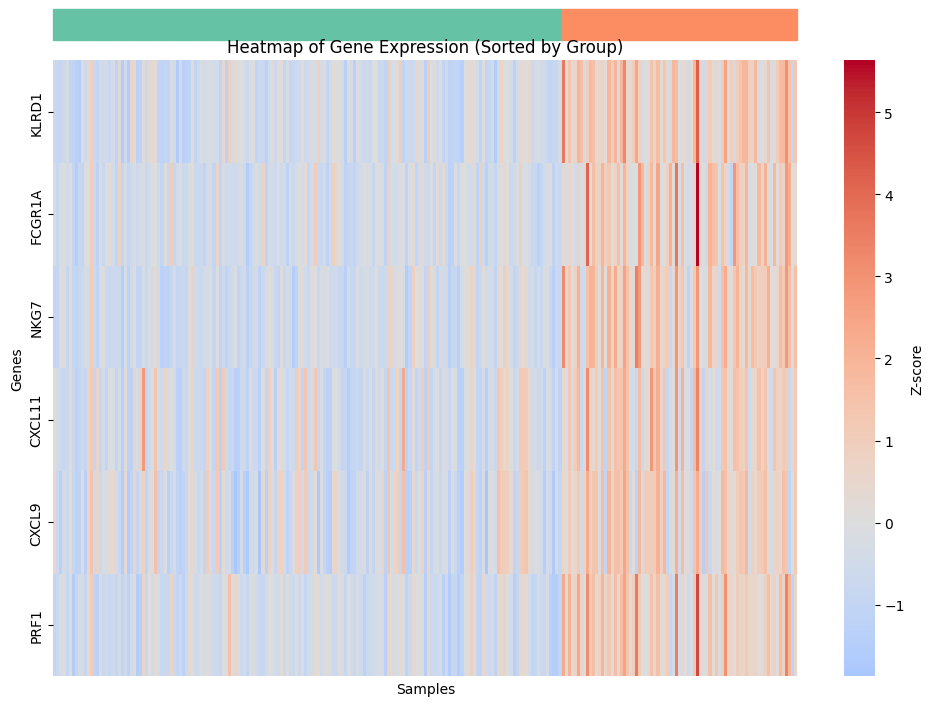

In [58]:
plot_expression_heatmap(
    data_lung,
    meta_lung,
    six_gene_biomarker,
    group_col="group")
